In [75]:
import yfinance as yf
import pandas as pd

In [76]:
# List of stock symbols for top 5 tech companies
tech_companies = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']

In [77]:
# Create an empty DataFrame to store all the data
all_data = pd.DataFrame()

In [78]:
# Loop through each stock symbol
for symbol in tech_companies:
    # Fetch the stock data for the year 2024
    stock = yf.Ticker(symbol)
    data = stock.history(start="2020-01-01", end="2024-12-31")
    
    # Add the company symbol as a column
    data['Company'] = symbol
    
    # Append this company's data to the main DataFrame
    all_data = all_data.append(data)

# Save the combined data to a CSV file
all_data.to_csv('Stock_data.csv')

print("Stock data for top 5 tech companies saved to CSV.")

/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_14745/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_14745/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_14745/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_14745/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)


Stock data for top 5 tech companies saved to CSV.


In [79]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5990 entries, 2020-01-02 00:00:00-05:00 to 2024-10-04 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          5990 non-null   float64
 1   High          5990 non-null   float64
 2   Low           5990 non-null   float64
 3   Close         5990 non-null   float64
 4   Volume        5990 non-null   int64  
 5   Dividends     5990 non-null   float64
 6   Stock Splits  5990 non-null   float64
 7   Company       5990 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 421.2+ KB


### 1. ARIMA Model: Stock Price Prediction

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import yfinance as yf


#### Load and preprocess the data:

                        Date       Open       High        Low      Close  \
0  2020-01-02 00:00:00-05:00  71.878856  72.936758  71.624090  72.876099   
1  2020-01-03 00:00:00-05:00  72.099664  72.931908  71.941952  72.167603   
2  2020-01-06 00:00:00-05:00  71.284400  72.781468  71.032056  72.742645   
3  2020-01-07 00:00:00-05:00  72.752363  73.009558  72.179742  72.400543   
4  2020-01-08 00:00:00-05:00  72.102091  73.868490  72.102091  73.565193   

      Volume  Dividends  Stock Splits Company  
0  135480400        0.0           0.0    AAPL  
1  146322800        0.0           0.0    AAPL  
2  118387200        0.0           0.0    AAPL  
3  108872000        0.0           0.0    AAPL  
4  132079200        0.0           0.0    AAPL  


/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_14745/71085388.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_data['Date'] = pd.to_datetime(apple_data['Date'])


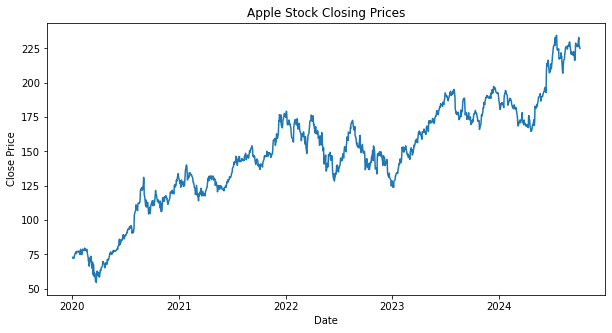

In [53]:
# Load the stock data
# Assuming your file is named 'Stock_data.csv'
stock_data = pd.read_csv('Stock_data.csv')

# Check the first few rows of data
print(stock_data.head())

# Filter data for Apple (or any one company)
# Assuming the data has a column 'Company' that indicates the stock symbol
apple_data = stock_data[stock_data['Company'] == 'AAPL']

# Convert the 'Date' column to datetime format and set it as the index
apple_data['Date'] = pd.to_datetime(apple_data['Date'])
apple_data.set_index('Date', inplace=True)

# Keep only the 'Close' price, which is usually used for stock prediction
apple_data_close = apple_data[['Close']]

# Plot the data to visualize
plt.figure(figsize=(10, 5))
plt.plot(apple_data_close)
plt.title('Apple Stock Closing Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


#### Differencing the data for stationarity (required for ARIMA):

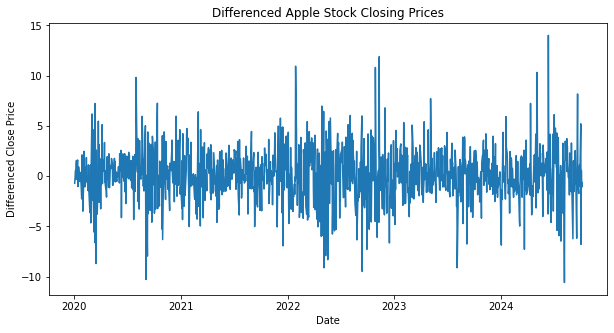

In [54]:
# Check if the data is stationary by differencing it
apple_data_diff = apple_data_close.diff().dropna()

# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(apple_data_diff)
plt.title('Differenced Apple Stock Closing Prices')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.show()


#### Train-test split:

In [55]:
# Split the data into train and test sets (80% train, 20% test)
train_size = int(len(apple_data_close) * 0.8)
train, test = apple_data_close[:train_size], apple_data_close[train_size:]

# Check the shapes of the sets
print("Train set size:", train.shape)
print("Test set size:", test.shape)


Train set size: (958, 1)
Test set size: (240, 1)


#### Build and train the ARIMA model:

In [56]:
# Build the ARIMA model
# The (p, d, q) parameters are chosen based on ACF and PACF plots or trial and error.
# You can try different combinations of (p, d, q) to get the best result.
model_arima = ARIMA(train, order=(5, 1, 0))  # Example (5, 1, 0), feel free to tune

# Fit the model
arima_result = model_arima.fit()

# Summary of the ARIMA model
print(arima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  958
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2284.802
Date:                Fri, 04 Oct 2024   AIC                           4581.604
Time:                        13:22:15   BIC                           4610.787
Sample:                             0   HQIC                          4592.719
                                - 958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0402      0.028     -1.433      0.152      -0.095       0.015
ar.L2         -0.0271      0.029     -0.946      0.344      -0.083       0.029
ar.L3         -0.0190      0.031     -0.614      0.5

/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [57]:
print(test.columns)

Index(['Close'], dtype='object')


#### Forecasting and evaluating the ARIMA model:

/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


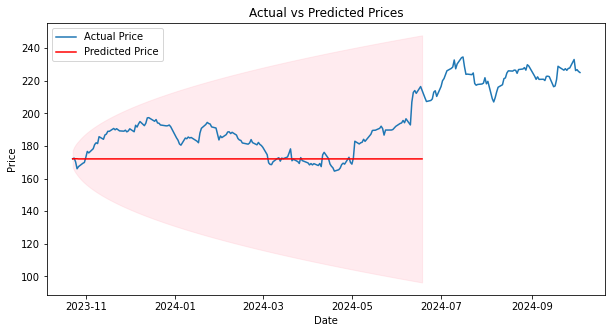

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Generate the forecast using the fitted ARIMA model
# Assume you want to forecast for the length of your test dataset
forecast_length = len(test)  # Length of the test dataset
forecast = arima_result.get_forecast(steps=forecast_length)
forecast_index = pd.date_range(start=test.index[0], periods=forecast_length, freq='D')  # Adjust frequency if necessary

# Get the predicted mean and confidence intervals
predicted_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Plot actual vs. predicted prices
plt.figure(figsize=(10, 5))
plt.plot(test.index, test['Close'], label='Actual Price')  # Replace 'Price' with the actual column name
plt.plot(forecast_index, predicted_mean, label='Predicted Price', color='red')
plt.fill_between(forecast_index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3)

plt.title('Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()



### 2. LSTM Model: Stock Price Prediction

In [59]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

#### Preprocess data for LSTM:

In [60]:
# Normalize the data using MinMaxScaler (LSTM requires scaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(apple_data_close)

# Prepare the data for LSTM
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Set time_step (window size)
time_step = 60

# Split the data into training and testing sets
train_size = int(len(scaled_data) * 0.8)
test_size = len(scaled_data) - train_size
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:len(scaled_data), :]

# Reshape into X=t, Y=t+1 for LSTM input
X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


#### Build and train the LSTM model:

In [69]:
# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dense(25))
model_lstm.add(Dense(1))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train, Y_train, batch_size=48, epochs=20)


Epoch 1/20


/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0661
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0042
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0023
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0013
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 9.8033e-04
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 9.6018e-04
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 8.8144e-04
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 8.5462e-04
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 8.4588e-04
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.6731e-04
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.9927e-04
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 8.0756e-04
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 8.2402e-04
Epoch 14/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 8.4854e-04
Epoch 15/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 

#### Predict and evaluate LSTM model:

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM RMSE: 193.98097370397787


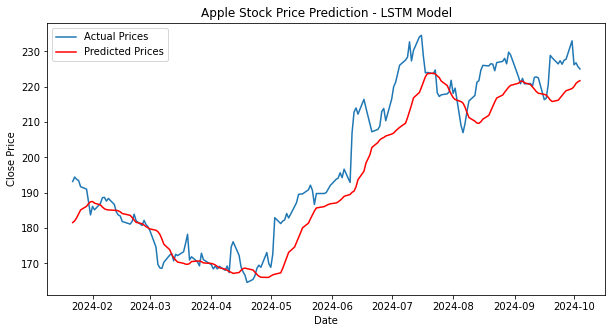

In [70]:
# Make predictions
train_predict = model_lstm.predict(X_train)
test_predict = model_lstm.predict(X_test)

# Inverse transform predictions to actual prices
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Calculate RMSE
rmse_lstm = np.sqrt(mean_squared_error(Y_test, test_predict))
print('LSTM RMSE:', rmse_lstm)

# Plot the predictions and actual prices
plt.figure(figsize=(10, 5))
plt.plot(apple_data_close.index[-len(Y_test):], scaler.inverse_transform(scaled_data[-len(Y_test):]), label='Actual Prices')
plt.plot(apple_data_close.index[-len(test_predict):], test_predict, label='Predicted Prices', color='red')
plt.title('Apple Stock Price Prediction - LSTM Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


                           Actual Prices  Predicted Prices Signal
Date                                                             
2024-01-22 00:00:00-05:00     193.157028        181.539337   Sell
2024-01-23 00:00:00-05:00     194.442154        182.020355   Sell
2024-01-24 00:00:00-05:00     193.764725        182.887573   Sell
2024-01-25 00:00:00-05:00     193.435989        184.001297   Sell
2024-01-26 00:00:00-05:00     191.692581        185.119827   Sell
...                                  ...               ...    ...
2024-09-30 00:00:00-04:00     233.000000        219.474243   Sell
2024-10-01 00:00:00-04:00     226.210007        220.041992   Sell
2024-10-02 00:00:00-04:00     226.779999        220.946991   Sell
2024-10-03 00:00:00-04:00     225.669998        221.422043   Sell
2024-10-04 00:00:00-04:00     225.029999        221.705933   Sell

[179 rows x 3 columns]


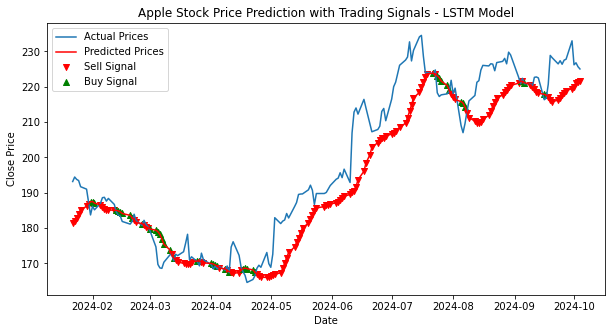

In [85]:
# Create a DataFrame for predicted prices
predicted_prices_df = pd.DataFrame(data=test_predict, index=apple_data_close.index[-len(test_predict):], columns=['Predicted Prices'])

# Create a DataFrame for actual prices
actual_prices_df = pd.DataFrame(data=scaler.inverse_transform(scaled_data[-len(Y_test):]), index=apple_data_close.index[-len(Y_test):], columns=['Actual Prices'])

# Combine both DataFrames
combined_df = actual_prices_df.join(predicted_prices_df)

# Generate trading signals
def generate_signals(df):
    signals = []
    for i in range(len(df)):
        if df['Predicted Prices'].iloc[i] > df['Actual Prices'].iloc[i]:
            signals.append('Buy')  # Buy signal
        elif df['Predicted Prices'].iloc[i] < df['Actual Prices'].iloc[i]:
            signals.append('Sell')  # Sell signal
        else:
            signals.append('Hold')  # Hold signal
    return signals

# Apply the function to generate signals
combined_df['Signal'] = generate_signals(combined_df)

# Display the trading signals
print(combined_df)

# Plotting actual vs predicted prices with signals
plt.figure(figsize=(10, 5))
plt.plot(combined_df.index, combined_df['Actual Prices'], label='Actual Prices')
plt.plot(combined_df.index, combined_df['Predicted Prices'], label='Predicted Prices', color='red')

# Mark Buy and Sell signals
for i in range(len(combined_df)):
    if combined_df['Signal'].iloc[i] == 'Buy':
        plt.scatter(combined_df.index[i], combined_df['Predicted Prices'].iloc[i], marker='^', color='green', label='Buy Signal' if 'Buy Signal' not in plt.gca().get_legend_handles_labels()[1] else "")
    elif combined_df['Signal'].iloc[i] == 'Sell':
        plt.scatter(combined_df.index[i], combined_df['Predicted Prices'].iloc[i], marker='v', color='red', label='Sell Signal' if 'Sell Signal' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title('Apple Stock Price Prediction with Trading Signals - LSTM Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [86]:
# Save the model
model_lstm.save('apple_stock_lstm_model.h5')  # Save as HDF5 file

# To load the model later:
from keras.models import load_model
loaded_model = load_model('apple_stock_lstm_model.h5')